In [141]:
import sys
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sys.path.append("/mnt/lareaulab/reliscu/code")

from parse_gtf import *
from junction2psi import *

pd.set_option('display.max_columns', None)

In [142]:
ctype_abundance_df1 = pd.read_csv("data/ctype_abundance/GTEx_cortex_counts_TMMF_All_501_outliers_removed_top_Qval_mods_PC1_ctype_abundance_filtered.csv", index_col=0)
ctype_abundance_df2 = pd.read_csv("data/ctype_abundance/GTEx_cortex_counts_TMMF_All_501_outliers_removed_47840genes_cleaned_44846genes_cleaned_mergeParam0.85_subsetCutoff1.427_Modules_top_corr_enriched_w_Claude_marker_genes_PC1_ctype_abundance.csv", index_col=0)

In [143]:
ctype_abundance_df2 = ctype_abundance_df2[["VLMC", "L2/3 IT"]]

In [144]:
ctype_abundance_df = pd.concat([ctype_abundance_df1, ctype_abundance_df2], axis=1)

In [145]:
ctype_abundance_df = ctype_abundance_df.rename(columns={"L2/3 IT": "Upper layer glutamatergic"})

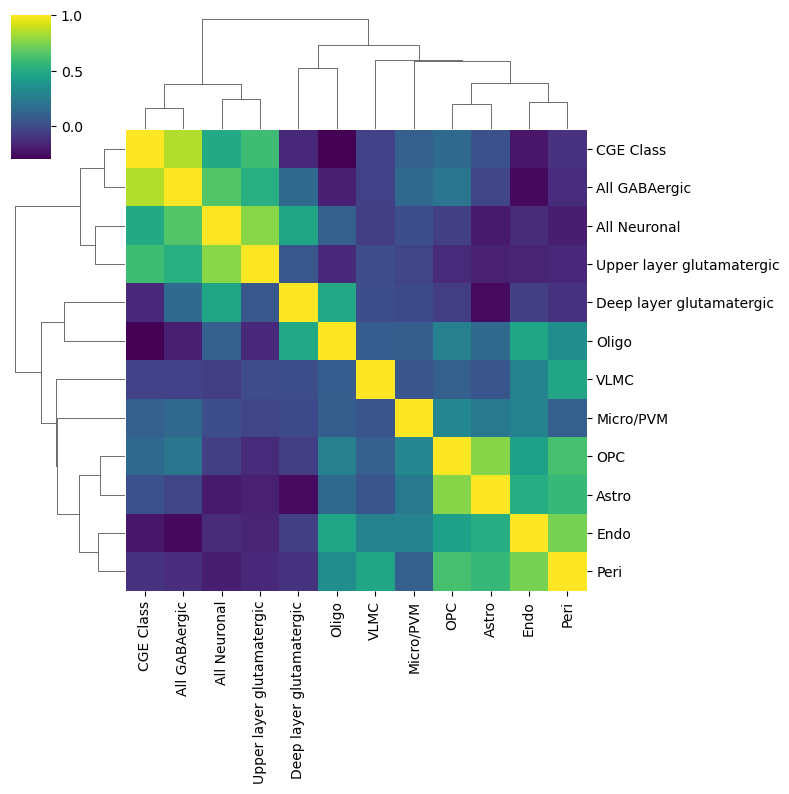

In [146]:
abund_corr_mat = ctype_abundance_df.corr()
sns.clustermap(abund_corr_mat, cmap='viridis', figsize=(8, 8))

In [147]:
expr_corr_df1 = pd.read_csv("data/corrs/GTEx_cortex_counts_TMMF_All_501_outliers_removed_top_Qval_mods_PC1_ctype_abundance_gene_expr_corr.csv", index_col=0)
expr_corr_df2 = pd.read_csv("data/corrs/GTEx_cortex_counts_TMMF_All_501_outliers_removed_47840genes_cleaned_44846genes_cleaned_mergeParam0.85_subsetCutoff1.427_Modules_top_corr_enriched_w_Claude_marker_genes_PC1_ctype_abundance_gene_expr_corr.csv", index_col=0)

In [148]:
expr_corr_df1 = expr_corr_df1.loc[:, expr_corr_df1.columns != "Oligo"]
expr_corr_df1.rename(columns={"L6 IT": "Deep layer glutamatergic", "AGARWAL_CTX_2020_OPC": "OPC", "kelley_oligo": "Oligo"}, inplace=True)
expr_corr_df1 = expr_corr_df1[ctype_abundance_df1.columns.tolist()]

In [149]:
expr_corr_df2 = expr_corr_df2[["VLMC", "L2/3 IT"]]
expr_corr_df2 = expr_corr_df2.rename(columns={"L2/3 IT": "Upper layer glutamatergic"})

In [150]:
expr_corr_df = pd.concat([expr_corr_df1, expr_corr_df2], axis=1)

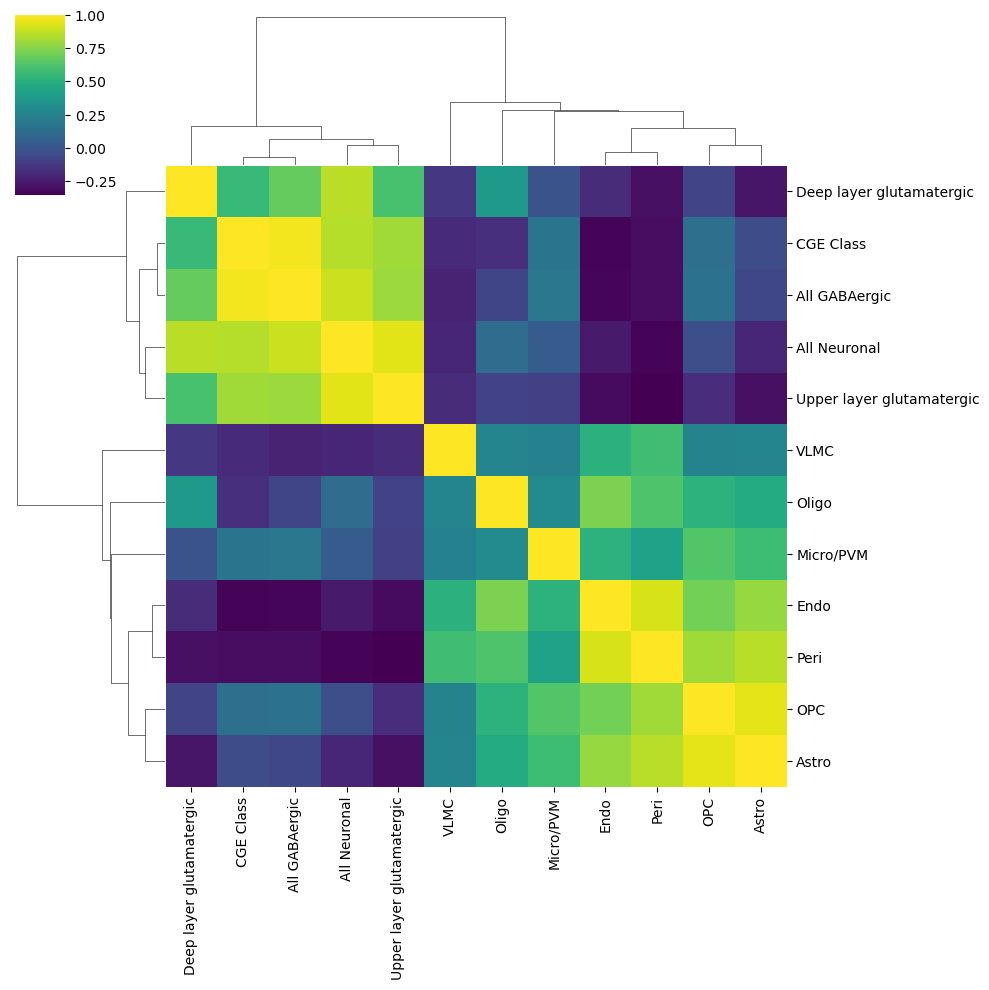

In [151]:
expr_corr_mat = expr_corr_df.corr()
sns.clustermap(expr_corr_mat, cmap='viridis',figsize=(10, 10))

In [152]:
ctype_abundance_df.to_csv("data/ctype_abundance/GTEx_cortex_counts_TMMF_All_501_outliers_removed_top_Qval_mods_PC1_ctype_abundance_filtered_47840genes_cleaned_44846genes_cleaned_mergeParam0.85_subsetCutoff1.427_Modules_top_corr_enriched_w_Claude_marker_genes_PC1_ctype_abundance.csv")